## Задача


\begin{cases}
\dfrac{dx}{dt} = x \left( 1 - 0.5x - \dfrac{2}{7} \alpha_2^{-2} y \right), \quad x(0) = x_0, \\[10pt]
\dfrac{dy}{dt} = y \left( 2\alpha_2 - 0.5y - 3.5\alpha_2^2 x \right), \quad y(0) = y_0, \\[10pt]
\dfrac{d\alpha_2}{dt} = \varepsilon (2 - 7\alpha_2 x), \quad \alpha_2(0) = \alpha_{20}; \quad t \in [0; T_k].
\end{cases}

#### Рекомендуемые значения начальных данных


$0 \le x_0 \le 3$,

 $0 \le y_0 \le 15$
 
 $\alpha_{20}$ близко к нулю, например,
можно положить $\alpha_{20} = 0.0001$;

 $T_k = 1500$. 
 
$\varepsilon \le 0.01$ 

### Что требуется?

1. Разработайте численный алгоритм решения задачи
Коши для нелинейной системы (2.25). Разработайте компью-
терную программу, оттестируйте ее. 
2. Проведите методические расчеты, направленные на выбор численного метода этой жесткой задачи.
3. Проведите численные исследования зависимости численного решения от начальных условий. Требуется изучить и представить наглядно зависимость численного решения задачи от начальных данных для $x, y, \alpha_2$ в указанных выше диапазонах
их изменений
4. Изучить зависимость решения задачи от значений параметров $\varepsilon ,T_k$ .

#### Вторая система

\begin{align*}
\frac{dx}{dt} &= x\left(2\alpha_1 - 0.5x - \alpha_1^2 \alpha_2^{-2} y\right), \quad x(0) = x_0, \\[1ex]
\frac{dy}{dt} &= y\left(2\alpha_2 - 0.5y - \alpha_1^{-2} \alpha_2^2 x\right), \quad y(0) = y_0, \\[1ex]
\frac{d\alpha_1}{dt} &= \varepsilon\left(2 - 2\alpha_1 \alpha_2^{-2} y\right), \quad \alpha_1(0) = \alpha_{10}, \\[1ex]
\frac{d\alpha_2}{dt} &= \varepsilon\left(2 - 2\alpha_1^{-2} \alpha_2 x\right), \quad \alpha_2(0) = \alpha_{20}; \qquad t \in [0; T_k].
\end{align*}



##### Рекомендуемые значения начальных данных


$0 \le x_0 \le 40$,

 $0 \le y_0 \le 40$
 
 $\alpha_{10}$ близко к нулю, например,
можно положить $\alpha_{10} = 0.0001$;

$\alpha_{20} = 10$


 $T_k = 2000$. 
 
$\varepsilon \le 0.01$ 


## Реализация

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from numba import njit
import time

from warnings import filterwarnings
filterwarnings("ignore", category=UserWarning)

### Система

In [14]:
@njit
def system_func(t, v, epsilon=0.05, extinction_threshold=0.001):
    x, y, a2 = v
    a2_reg = a2 if abs(a2) > 1e-10 else 1e-10
    
    dxdt = x * (1 - 0.5 * x - (2/7) * (a2_reg**-2) * y)
    dydt = y * (2 * a2 - 0.5 * y - 3.5 * (a2_reg**2) * x)
    da2dt = epsilon * (2 - 7 * a2 * x)
    
    if x < extinction_threshold:
        dxdt = 0
    if y < extinction_threshold:
        dydt = 0
    if a2 < extinction_threshold:
        da2dt = 0
    
    return np.array([dxdt, dydt, da2dt])

### Функции методов

Эйлеры, Адамсы, Гир

In [3]:
@njit
def rk4_step_fast(f, t, y, h):
    k1 = f(t, y)
    k2 = f(t + h/2, y + h/2 * k1)
    k3 = f(t + h/2, y + h/2 * k2)
    k4 = f(t + h, y + h * k3)
    return y + h/6 * (k1 + 2*k2 + 2*k3 + k4)

@njit
def euler_explicit(f, y0, t_span, h):
    n_steps = int(np.ceil((t_span[1] - t_span[0]) / h)) + 1
    t = np.linspace(t_span[0], t_span[1], n_steps)
    y = np.zeros((n_steps, len(y0)))
    y[0] = y0
    for i in range(n_steps - 1):
        y[i+1] = y[i] + h * f(t[i], y[i])
    return t, y

@njit
def implicit_euler_fast(f, y0, t_span, h, tol=1e-7, max_iter=100):
    n_steps = int(np.ceil((t_span[1] - t_span[0]) / h)) + 1
    t = np.linspace(t_span[0], t_span[1], n_steps)
    y = np.zeros((n_steps, len(y0)))
    y[0] = y0
    
    for i in range(n_steps - 1):
        # Начальное приближение
        y_guess = y[i] + h * f(t[i], y[i])
        
        # Простая итерация (Метод Пикара)
        for _ in range(max_iter):
            y_new = y[i] + h * f(t[i+1], y_guess)
            if np.linalg.norm(y_new - y_guess) < tol:
                break
            y_guess = y_new
        y[i+1] = y_new
    return t, y

@njit
def modified_euler(f, y0, t_span, h):
    n_steps = int(np.ceil((t_span[1] - t_span[0]) / h)) + 1
    t = np.linspace(t_span[0], t_span[1], n_steps)
    y = np.zeros((n_steps, len(y0)))
    y[0] = y0
    
    for i in range(n_steps - 1):
        k1 = f(t[i], y[i])
        k2 = f(t[i+1], y[i] + h * k1)
        y[i+1] = y[i] + (h/2) * (k1 + k2)
        
    return t, y


# =====================================================================
# 1. Адамс-Башфорт 4 (Явный - без итераций)
# =====================================================================
@njit
def adams_b(f, y0, t_span, h):
    n_steps = int(np.ceil((t_span[1] - t_span[0]) / h)) + 1
    t = np.linspace(t_span[0], t_span[1], n_steps)
    y = np.zeros((n_steps, len(y0)))
    y[0] = y0
    
    for i in range(3):
        y[i+1] = rk4_step_fast(f, t[i], y[i], h)
        
    f0 = f(t[0], y[0])
    f1 = f(t[1], y[1])
    f2 = f(t[2], y[2])
    f3 = f(t[3], y[3])
    
    for i in range(3, n_steps - 1):
        y[i+1] = y[i] + (h/24) * (55*f3 - 59*f2 + 37*f1 - 9*f0)
        f0, f1, f2, f3 = f1, f2, f3, f(t[i+1], y[i+1])
        
    return t, y

@njit
def adams_m(f, y0, t_span, h, tol=1e-7, max_iter=100):
    n_steps = int(np.ceil((t_span[1] - t_span[0]) / h)) + 1
    t = np.linspace(t_span[0], t_span[1], n_steps)
    y = np.zeros((n_steps, len(y0)))
    y[0] = y0
    
    for i in range(3):
        y[i+1] = rk4_step_fast(f, t[i], y[i], h)
        
    # История для метода Мултона: нам нужны f_{i-2}, f_{i-1}, f_i
    f1 = f(t[1], y[1])
    f2 = f(t[2], y[2])
    f3 = f(t[3], y[3])
    
    cnt = 0
    for i in range(3, n_steps - 1):
        # Начальное приближение (берем просто значение с прошлого шага)
        y_guess = y[i] + h * f3
        
        # Цикл простых итераций
        for _ in range(max_iter):
            # Формула AM4: y_{i+1} = y_i + h/24 * (9*f_{i+1} + 19*f_i - 5*f_{i-1} + f_{i-2})
            cnt+=1
            y_new = y[i] + (h/24) * (9*f(t[i+1], y_guess) + 19*f3 - 5*f2 + f1)
            
            if np.linalg.norm(y_new - y_guess) < tol:
                break
            y_guess = y_new
            
        y[i+1] = y_new
        f1, f2, f3 = f2, f3, f(t[i+1], y[i+1])
    print("ADAMS_M: In average, it took", cnt//(n_steps-4), "iterations per step for convergence.")
    return t, y

@njit
def adams_bm(f, y0, t_span, h):
    """
    Схема PECE: Predict (AB4) -> Evaluate -> Correct (AM4) -> Evaluate.
    Делает строго ОДНУ простую итерацию корректора.
    """
    n_steps = int(np.ceil((t_span[1] - t_span[0]) / h)) + 1
    t = np.linspace(t_span[0], t_span[1], n_steps)
    y = np.zeros((n_steps, len(y0)))
    y[0] = y0
    
    for i in range(3):
        y[i+1] = rk4_step_fast(f, t[i], y[i], h)
        
    f0 = f(t[0], y[0])
    f1 = f(t[1], y[1])
    f2 = f(t[2], y[2])
    f3 = f(t[3], y[3])
    
    for i in range(3, n_steps - 1):
        # 1. PREDICT (Предиктор AB4)
        y_predict = y[i] + (h/24) * (55*f3 - 59*f2 + 37*f1 - 9*f0)
        f_predict = f(t[i+1], y_predict)
        # 3. CORRECT (Корректор AM4 - одна простая итерация)
        y[i+1] = y[i] + (h/24) * (9*f_predict + 19*f3 - 5*f2 + f1)
        f0, f1, f2, f3 = f1, f2, f3, f(t[i+1], y[i+1])
        
    return t, y


@njit
def gear_4(f, y0, t_span, h, tol=1e-7, max_iter=100):
    n_steps = int(np.ceil((t_span[1] - t_span[0]) / h)) + 1
    t = np.linspace(t_span[0], t_span[1], n_steps)
    y = np.zeros((n_steps, len(y0)))
    y[0] = y0
    
    for i in range(3):
        y[i+1] = rk4_step_fast(f, t[i], y[i], h)
        
    cnt = 0
    for i in range(3, n_steps - 1):
        y_guess = y[i] + h * f(t[i], y[i])
        history = (48/25)*y[i] - (36/25)*y[i-1] + (16/25)*y[i-2] - (3/25)*y[i-3]
        
        reltol = tol ** 4
        # Простая итерация
        for _ in range(max_iter):
            y_new = history + (12/25)*h * f(t[i+1], y_guess)
            cnt+=1
            if np.linalg.norm(y_new - y_guess) < reltol:
                break
            y_guess = y_new
        y[i+1] = y_new
    print("Gear: In average, it took", cnt//(n_steps-4), "iterations per step for convergence.")
    return t, y

# ---------------------------------------------------------
# ИНФРАСТРУКТУРА ДЛЯ ТОЧНОГО ЗАМЕРА ВРЕМЕНИ
# ---------------------------------------------------------

def run_with_profiling(method, name, f, y0, t_span, h):
    """
    Запускает метод, отсекая время компиляции Numba, 
    и замеряет чистое время выполнения.
    """
    # 1. Прогрев (Warm-up): заставляем Numba скомпилировать код
    # Берем микро-отрезок, чтобы не ждать долго
    _ = method(f, y0, [t_span[0], t_span[0] + h*2], h)
    
    # 2. Боевой запуск с таймером (используем perf_counter для наносекундной точности)
    start_time = time.perf_counter()
    t_res, y_res = method(f, y0, t_span, h)
    end_time = time.perf_counter()
    
    execution_time = end_time - start_time
    
    # Проверка на "взрыв" (расходимость простых итераций)
    if np.any(np.isnan(y_res)) or np.any(np.isinf(y_res)):
        status = "ВЗРЫВ (NaN/Inf - итерации разошлись)"
    else:
        status = "Успешно"
        
    print(f"[{name}] Время: {execution_time:.6f} сек | Статус: {status}")
    return t_res, y_res

y0_initial = np.array([1.5, 7.5, 0.01])
t_max = 100.0
# run_with_profiling(gear_4, "Gear 4-й порядок", system_func, y0_initial, [0.0, t_max], h=0.000_01)

In [ ]:
# #slow
# def rk4_step(f, t, y, h):
#     k1 = f(t, y)
#     k2 = f(t + h/2, y + h/2 * k1)
#     k3 = f(t + h/2, y + h/2 * k2)
#     k4 = f(t + h, y + h * k3)
#     return y + h/6 * (k1 + 2*k2 + 2*k3 + k4)

# def euler_explicit(f, y0, t_span, h):
#     t = np.arange(t_span[0], t_span[1] + h, h)
#     y = np.zeros((len(t), len(y0)))
#     y[0] = y0
#     for i in range(len(t)-1):
#         y[i+1] = y[i] + h * f(t[i], y[i])
#     return t, y

# def implicit_euler(f, y0, t_span, h, tol=1e-7, max_iter=20):
#     t = np.arange(t_span[0], t_span[1] + h, h)
#     y = np.zeros((len(t), len(y0)))
#     y[0] = y0
#     for i in range(len(t)-1):
#         y_guess = y[i] + h * f(t[i], y[i])
#         for _ in range(max_iter):
#             y_new = y[i] + h * f(t[i+1], y_guess)
#             if np.linalg.norm(y_new - y_guess) < tol: break
#             y_guess = y_new
#         y[i+1] = y_new
#     return t, y

# def modified_euler(f, y0, t_span, h):
#     t = np.arange(t_span[0], t_span[1] + h, h)
#     y = np.zeros((len(t), len(y0)))
#     y[0] = y0
#     for i in range(len(t)-1):
#         k1 = f(t[i], y[i])
#         k2 = f(t[i+1], y[i] + h * k1)
#         y[i+1] = y[i] + (h/2) * (k1 + k2)
#     return t, y

# def adams_bashforth_4(f, y0, t_span, h):
#     t = np.arange(t_span[0], t_span[1] + h, h)
#     y = np.zeros((len(t), len(y0)))
#     y[0] = y0
#     for i in range(3):
#         y[i+1] = rk4_step(f, t[i], y[i], h)
    
#     f_vals = [f(t[i], y[i]) for i in range(4)]
#     for i in range(3, len(t)-1):
#         y[i+1] = y[i] + h/24 * (55*f_vals[3] - 59*f_vals[2] + 37*f_vals[1] - 9*f_vals[0])
#         f_vals.pop(0)
#         f_vals.append(f(t[i+1], y[i+1]))
#     return t, y

# def gear_4(f, y0, t_span, h, tol=1e-7):
#     t = np.arange(t_span[0], t_span[1] + h, h)
#     y = np.zeros((len(t), len(y0)))
#     y[0] = y0
#     for i in range(3): y[i+1] = rk4_step(f, t[i], y[i], h)
    
#     for i in range(3, len(t)-1):
#         # Начальное приближение (предиктор)
#         y_guess = y[i] + h * f(t[i], y[i])
#         for _ in range(20):
#             y_new = (48/25)*y[i] - (36/25)*y[i-1] + (16/25)*y[i-2] - (3/25)*y[i-3] + (12/25)*h*f(t[i+1], y_guess)
#             if np.linalg.norm(y_new - y_guess) < tol: break
#             y_guess = y_new
#         y[i+1] = y_new
#     return t, y

### Таблички сходимости

In [50]:
def compute_convergence_orders(methods, system_func, y0, t_span, h_start, n_refinements, ethalon_sol=None):
    data = []
    prev_results = {name: {'t': None, 'y': None} for name in methods}
    
    h = h_start
    for i in range(n_refinements):
        row = {'h': h}
        
        for name, method_func in methods.items():
            # Запускаем метод
            t_curr, y_curr = method_func(system_func, y0, t_span, h)
            
            error = np.nan
            
            # Проверка на взрыв (NaN или Inf)
            if np.any(np.isnan(y_curr)) or np.any(np.isinf(y_curr)):
                pass # Ошибка остается NaN
            elif ethalon_sol is not None:
                # Оценка по эталонному решению
                y_true = ethalon_sol(t_curr)
                error = np.max(np.abs(y_curr - y_true))
            else:
                # Оценка по правилу Рунге (по отношению к предыдущему, более грубому шагу)
                t_prev = prev_results[name]['t']
                y_prev = prev_results[name]['y']
                
                if t_prev is not None and not (np.any(np.isnan(y_prev)) or np.any(np.isinf(y_prev))):
                    # Исключаем ошибку размерностей: интерполируем текущее (более точное) решение 
                    # на сетку предыдущего (более грубого) решения
                    interpolator = interp1d(t_curr, y_curr, axis=0, kind='linear', bounds_error=False, fill_value="extrapolate")
                    y_curr_aligned = interpolator(t_prev)
                    error = np.max(np.abs(y_curr_aligned - y_prev))
            
            row[name] = error
            prev_results[name] = {'t': t_curr, 'y': y_curr}
            
            # Вычисление порядка p
            p_key = f"p_{name}"
            row[p_key] = np.nan
            
            if i > 0:
                err_prev = data[i-1][name]
                if pd.notna(err_prev) and pd.notna(error) and error > 0:
                    order = np.log2(err_prev / error)
                    row[p_key] = round(order, 2)
                
        data.append(row)
        h /= 2
        
    return pd.DataFrame(data)

In [22]:
y0_system = np.array([1.5, 7.5, 0.001], dtype=np.float64)
t_range = np.array([0.0, 0.001], dtype=np.float64)
eps_param = 0.01

steps = 10

pure_system = lambda t, v: system_func(t, v, eps_param)
sol = solve_ivp(pure_system, t_range, y0_system, method='BDF', atol=1e-12, rtol=1e-12)
ethalon_func = interp1d(sol.t, sol.y, axis=1, kind='cubic', fill_value="extrapolate")

my_methods = {
    "Euler": euler_explicit,
    "ModEuler": modified_euler,
    "EulerImpl": implicit_euler_fast,
    "Adams4": adams_b,
    "AdamsM": adams_m,
    "AdamsBM": adams_bm,
    "Gear4": gear_4
}

df_results = compute_convergence_orders(
    my_methods, 
    system_func, 
    y0_system, 
    t_range, 
    h_start=t_range[1]/steps, 
    n_refinements=12, 
    # ethalon_sol=lambda t: ethalon_func(t).T
)

df_results

ADAMS_M: In average, it took 100 iterations per step for convergence.
Gear: In average, it took 100 iterations per step for convergence.
ADAMS_M: In average, it took 100 iterations per step for convergence.
Gear: In average, it took 100 iterations per step for convergence.
ADAMS_M: In average, it took 100 iterations per step for convergence.
Gear: In average, it took 100 iterations per step for convergence.
ADAMS_M: In average, it took 100 iterations per step for convergence.
Gear: In average, it took 100 iterations per step for convergence.
ADAMS_M: In average, it took 100 iterations per step for convergence.
Gear: In average, it took 100 iterations per step for convergence.
ADAMS_M: In average, it took 100 iterations per step for convergence.
Gear: In average, it took 100 iterations per step for convergence.
ADAMS_M: In average, it took 100 iterations per step for convergence.
Gear: In average, it took 100 iterations per step for convergence.
ADAMS_M: In average, it took 1 iterations

,h,Euler,p_Euler,ModEuler,p_ModEuler,EulerImpl,p_EulerImpl,Adams4,p_Adams4,AdamsM,p_AdamsM,AdamsBM,p_AdamsBM,Gear4,p_Gear4
0,1.000000e-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5.000000e-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2.500000e-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.250000e-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,6.250000e-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,3.125000e-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1.562500e-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,7.812500e-07,3.361651e+06,NaN,1.427905e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,3.906250e-07,1.050991e+00,21.61,6.956042e-01,20.97,2.522767e+06,NaN,NaN,NaN,0.123629,NaN,2.125334e+06,NaN,0.123629,NaN
9,1.953125e-07,2.627501e-01,2.00,9.845818e-02,2.82,7.401654e-02,25.02,NaN,NaN,0.004300,4.85,1.645395e-02,26.94,0.010477,3.56


### Функции, рисующие графики

In [ ]:
y0 = 1.5
x0 = 7.5
a0 = 0.01

t_max = 100

y0_initial = np.array([y0, x0, a0], dtype=np.float64)
def draw_plots(y0_initial, t_max, h, method, **kwargs):
    t_range_plot = np.array([0, t_max], dtype=np.float64)
    t_plot, y_plot = method(system_func, y0_initial, t_range_plot, h=h)

    plt.plot(t_plot, y_plot[:, 0], label=f'x(t) {h}', color='blue',  **kwargs)
    plt.plot(t_plot, y_plot[:, 1], label=f'y(t) {h}', color='green', **kwargs)
    plt.plot(t_plot, y_plot[:, 2], label=f'alpha2(t) {h}', color='red', **kwargs)
    plt.xlabel('Время t')
    plt.ylabel('Values')
    plt.title('Combined Trajectories')
    plt.legend()
    plt.grid(True)

# plt.figure(figsize=(8, 6))
# plt.plot(y_plot[:, 0], y_plot[:, 1], color='purple')
# plt.xlabel('x')
# plt.ylabel('y')
# plt.title('Phase Portrait (x vs y)')
# plt.grid(True)
# plt.show()

plt.figure(figsize=(10, 6))
draw_plots(y0_initial, t_max=t_max, h=0.000_098, method=gear_4, ls='--', alpha=0.4, lw=3)
draw_plots(y0_initial, t_max=t_max, h=0.000_001, method=gear_4,  ls='-')

Gear: In average, it took 2 iterations per step for convergence.


#### Фазовые портреты

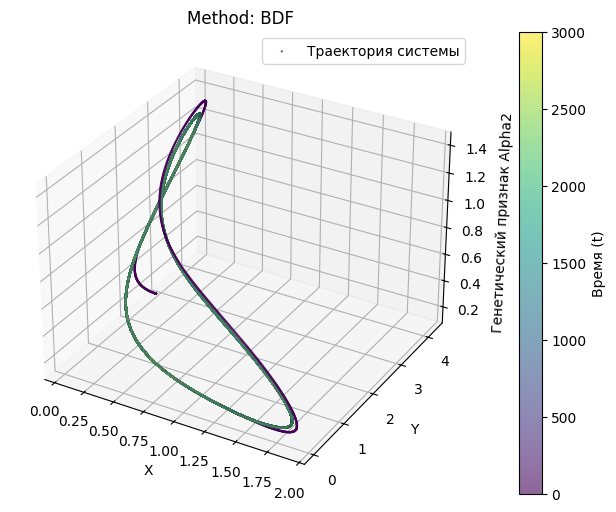

In [19]:
x0 = 0.4
y0 = 1.4
a0 = 0.5
eps = 0.05

t_max = 3000

y0_initial = np.array([x0, y0, a0], dtype=np.float64)
mets = [
    # 'Radau', 
    'BDF',
    # "LSODA"
        ]

eps_sys = lambda t, v: system_func(t, v, epsilon=eps)

_, axes = plt.subplots(len(mets), 1, figsize=(12, len(mets)*6), squeeze=True, subplot_kw={'projection': '3d'},)
axes = np.atleast_1d(axes)  # На случай, если будет только один метод

for i, met in enumerate(mets):
    res = solve_ivp(eps_sys, [0, t_max], y0_initial, method=met, atol=1e-12, rtol=1e-12)
    sc = axes[i].scatter(res.y[0], res.y[1], res.y[2], 
                    label='Траектория системы',
                         c=res.t, s=0.5, alpha=0.6)
    axes[i].set_xlabel("X")
    axes[i].set_ylabel("Y")
    axes[i].set_zlabel("Генетический признак Alpha2")
    # axes[i].set_ylim(0, 20)
    axes[i].set_title(f"Method: {met}")
    axes[i].legend()
    
    cbar = axes[i].figure.colorbar(sc, ax=axes[i])
    cbar.set_label('Время (t)')  # Название для хитбара

In [20]:
import numpy as np
import plotly.graph_objects as go
from scipy.integrate import solve_ivp

x0 = 0.4
y0 = 1.4
a0 = 0.5
eps = 0.05

t_max = 3000


y0_initial = np.array([x0, y0, a0], dtype=np.float64)
eps_sys = lambda t, v: system_func(t, v, epsilon=eps)

# Расчет системы точным методом BDF
res = solve_ivp(eps_sys, [0, t_max], y0_initial, method='BDF', atol=1e-12, rtol=1e-12)

# Данные для графика (можно не прореживать, так как статика работает быстро)
x_vals = res.y[0]
y_vals = res.y[1]
a_vals = res.y[2]
t_vals = res.t

# --- 2. Построение интерактивного 3D графика ---
fig = go.Figure(data=[go.Scatter3d(
    x=x_vals, 
    y=y_vals, 
    z=a_vals,
    mode='lines',
    line=dict(
        color=t_vals,          # Градиент цвета показывает течении времени
        colorscale='Viridis',  # Плавный переход от фиолетового (t=0) к желтому (t=3000)
        width=4,
        colorbar=dict(
            title='Время (t)',
            thickness=20
        )
    ),
    name='Траектория системы'
)])

# Настройка осей и внешнего вида
fig.update_layout(
    title=dict(
        text='Интерактивный фазовый портрет экогенетической системы (3D)',
        x=0.5
    ),
    scene=dict(
        xaxis=dict(title='Популяция X', gridcolor='lightgray'),
        yaxis=dict(title='Популяция Y', gridcolor='lightgray'),
        zaxis=dict(title='Признак Alpha2', gridcolor='lightgray'),
        aspectmode='cube', # Честные пропорции, чтобы куб не искажал форму петли
        backgroundcolor='white'
    ),
    width=1000,
    height=800,
    margin=dict(l=0, r=0, b=0, t=50)
)

# Вывод графика в браузер
fig.show()

ValueError: Invalid property specified for object of type plotly.graph_objs.layout.Scene: 'backgroundcolor'

Did you mean "bgcolor"?

    Valid properties:
        annotations
            A tuple of
            :class:`plotly.graph_objects.layout.scene.Annotation`
            instances or dicts with compatible properties
        annotationdefaults
            When used in a template (as
            layout.template.layout.scene.annotationdefaults), sets
            the default property values to use for elements of
            layout.scene.annotations
        aspectmode
            If "cube", this scene's axes are drawn as a cube,
            regardless of the axes' ranges. If "data", this scene's
            axes are drawn in proportion with the axes' ranges. If
            "manual", this scene's axes are drawn in proportion
            with the input of "aspectratio" (the default behavior
            if "aspectratio" is provided). If "auto", this scene's
            axes are drawn usi

In [ ]:
# 4. Convergence Order Plot (Log-Log)
print("Generating convergence plot...")
plt.figure(figsize=(10, 6))
for name in my_methods.keys():
    # Filter out NaNs for plotting
    valid_mask = ~df_results[name].isna()
    plt.loglog(df_results.loc[valid_mask, 'h'], df_results.loc[valid_mask, name], 'o-', label=name)

plt.xlabel('Step size h')
plt.ylabel('Max Absolute Error')
plt.title('Convergence Order Analysis')
plt.grid(True, which="both", ls="-")
plt.legend()
plt.show()

# Код Гемини

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

# 1. СИСТЕМА УРАВНЕНИЙ
@njit
def func(t, state, epsilon):
    x, y, alpha2 = state
    if alpha2 < 1e-12: alpha2 = 1e-12 # Защита от деления на ноль
        
    dxdt = x * (1 - 0.5*x - (2/7)*(alpha2**-2)*y)
    dydt = y * (2*alpha2 - 0.5*y - 3.5*(alpha2**2)*x)
    dalpha2dt = epsilon * (2 - 7*alpha2*x)
    
    return np.array([dxdt, dydt, dalpha2dt])

# 2. АНАЛИТИЧЕСКИЙ ЯКОБИАН
@njit
def system_jacobian(state, epsilon):
    x, y, alpha2 = state
    if alpha2 < 1e-12: alpha2 = 1e-12
    
    J = np.zeros((3, 3))
    
    J[0, 0] = 1 - x - (2/7)*(alpha2**-2)*y
    J[0, 1] = -(2/7)*(alpha2**-2)*x
    J[0, 2] = (4/7)*(alpha2**-3)*x*y
    
    J[1, 0] = -3.5*(alpha2**2)*y
    J[1, 1] = 2*alpha2 - y - 3.5*(alpha2**2)*x
    J[1, 2] = 2*y - 7*alpha2*x*y
    
    J[2, 0] = -7*epsilon*alpha2
    J[2, 1] = 0.0
    J[2, 2] = -7*epsilon*x
    
    return J

# 3. ВАШ СОБСТВЕННЫЙ ЖЕСТКИЙ РЕШАТЕЛЬ (Неявный Эйлер)
@njit
def implicit_euler_newton(func,y0, t_span, h, epsilon, tol=1e-7, max_iter=20):
    n_steps = int((t_span[1] - t_span[0]) / h) + 1
    t = np.linspace(t_span[0], t_span[1], n_steps)
    y = np.zeros((n_steps, 3))
    y[0] = y0
    
    I = np.eye(3) # Единичная матрица
    
    for i in range(n_steps - 1):
        # Начальное приближение (Предиктор)
        y_guess = y[i] + h * func(t[i], y[i], epsilon)
        
        # Метод Ньютона (Корректор)
        for _ in range(max_iter):
            # Вектор невязки: F(y) = y_new - y_old - h * f(y_new)
            F = y_guess - y[i] - h * func(t[i+1], y_guess, epsilon)
            
            # Матрица системы: J_F = I - h * J_f
            J_f = system_jacobian(y_guess, epsilon)
            J_F = I - h * J_f
            if np.any(np.isnan(J_F)) or np.any(np.isinf(J_F)):
                print("Критическая ошибка: Якобиан содержит Inf/NaN на шаге", i)
                return t[:i], y[:i] # Вернуть то, что успели посчитать
            # Решение линейной системы J_F * dy = -F
            dy = np.linalg.solve(J_F, -F)
            y_guess = y_guess + dy
            
            # Условие выхода из итераций
            if np.linalg.norm(dy) < tol:
                break
                
        y[i+1] = y_guess
        
    return t, y

In [40]:
initial_state = np.array([1.5, 7.5, 0.001], dtype=np.float64)
t_span = np.array([0, 200], dtype=np.float64) # Короткий интервал для теста
epsilon = 0.01


res = solve_ivp(system_equations, t_span, initial_state, args=(epsilon,), method='BDF', rtol=1e-10, atol=1e-10)

ethalon = res.sol # Это объект-функция, его можно вызывать как ethalon(t_curr)
methods = {'impE': implicit_euler_newton}
df_results = compute_convergence_orders(methods, initial_state, t_span, epsilon, h_start=0.1, n_refinements=10, ethalon_sol=ethalon)
df_results

Критическая ошибка: Якобиан содержит Inf/NaN на шаге 4


,h,impE,p_impE
0,0.100000,NaN,NaN
1,0.050000,2.211518e+50,NaN
2,0.025000,6.532713e+02,157.8899
3,0.012500,1.389711e+01,5.5548
4,0.006250,1.746396e+01,-0.3296
5,0.003125,1.469971e+00,3.5705
6,0.001563,7.992980e-03,7.5228
7,0.000781,4.020657e-03,0.9913
8,0.000391,2.016456e-03,0.9956
9,0.000195,1.811816e-03,0.1544


Критическая ошибка: Якобиан содержит Inf/NaN на шаге 4


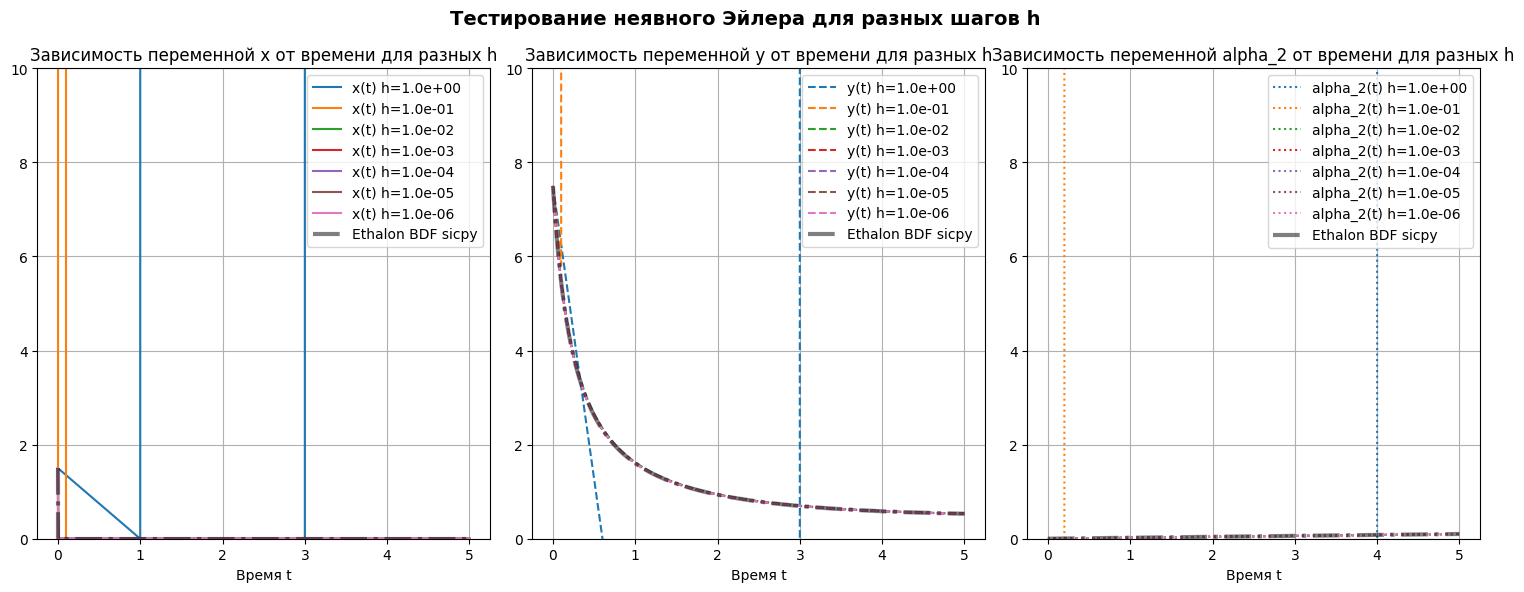

In [15]:
initial_state = np.array([1.5, 7.5, 0.001], dtype=np.float64)
t_span = np.array([0, 5], dtype=np.float64) # Короткий интервал для теста
epsilon = 0.01

h_vals = 0.1 ** np.arange(0, 7)
_, axes = plt.subplots(1, 3, figsize=(15, 6))
for h in h_vals:
    t, y = implicit_euler_newton(initial_state, t_span, h, epsilon)
    if np.any(np.isnan(y)) or np.any(np.isinf(y)):
        print(f"h={h:.1e} - РЕШЕНИЕ РАСХОДИТСЯ (NaN/Inf)")
        continue
    axes[0].plot(t, y[:, 0], label=f'x(t) h={h:.1e}')
    axes[1].plot(t, y[:, 1], '--', label=f'y(t) h={h:.1e}')
    axes[2].plot(t, y[:, 2], ':', label=f'alpha_2(t) h={h:.1e}')

t, y = solve_ivp(system_equations, t_span, initial_state, args=(epsilon,), method='BDF', rtol=1e-6, atol=1e-8).t, solve_ivp(system_equations, t_span, initial_state, args=(epsilon,), method='BDF', rtol=1e-6, atol=1e-8).y.T
axes[0].plot(t, y[:, 0], '-.', label=f'Ethalon BDF sicpy', alpha=0.5, color='black', lw=3)
axes[1].plot(t, y[:, 1], '-.', label=f'Ethalon BDF sicpy', alpha=0.5, color='black', lw=3)
axes[2].plot(t, y[:, 2], '-.', label=f'Ethalon BDF sicpy', alpha=0.5, color='black', lw=3)

for i in range(3):
    axes[i].grid(True)
    axes[i].set_xlabel('Время t')
    axes[i].set_ylim(0, 10)
    axes[i].legend()
    axes[i].set_title(f'Зависимость переменной {["x", "y", "alpha_2"][i]} от времени для разных h')

plt.suptitle('Тестирование неявного Эйлера для разных шагов h', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

BDF success: True | n_steps = 150001


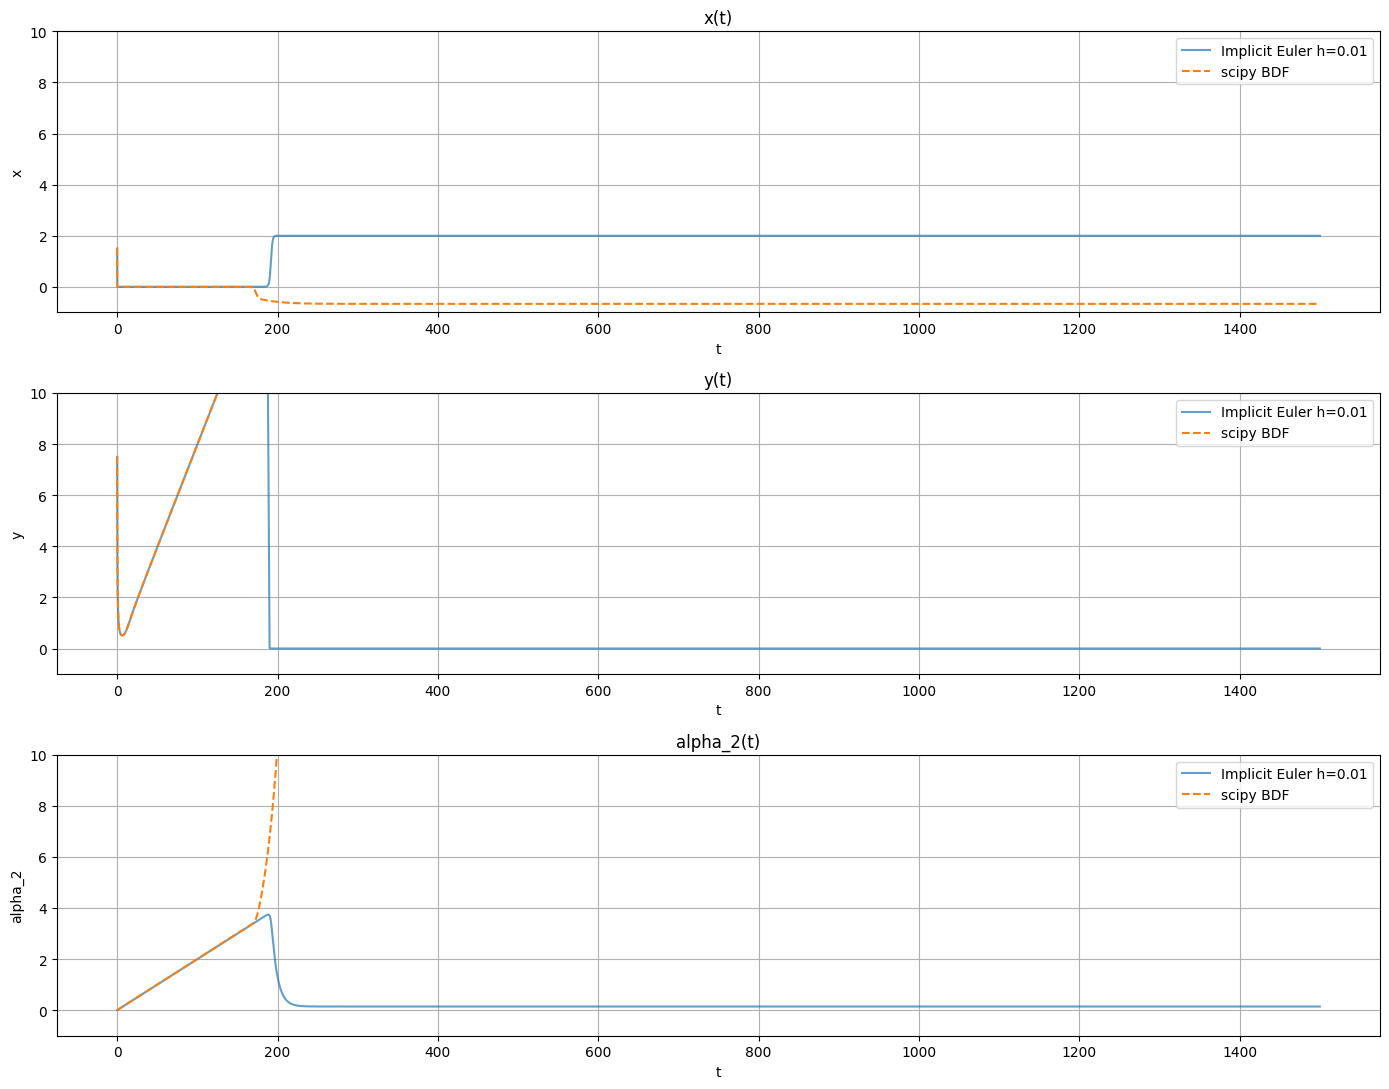

In [55]:
t_final = 1500.0
h_ie = 0.01
t_span_long = np.array([0.0, t_final], dtype=np.float64)

# Неявный Эйлер с шагом 0.1
t_ie, y_ie = implicit_euler_newton(initial_state, t_span_long, h_ie, epsilon)

# Адаптивный BDF из scipy на той же длине промежутка
t_bdf = np.linspace(0.0, t_final, int(t_final / h_ie) + 1)
sol_bdf = solve_ivp(
    system_equations,
    t_span_long,
    initial_state,
    args=(epsilon,),
    method='BDF',
    t_eval=t_bdf,
    rtol=1e-12,
    atol=1e-12
)

print("BDF success:", sol_bdf.success, "| n_steps =", len(sol_bdf.t))

plt.figure(figsize=(14, 11))

for idx, name in enumerate(['x', 'y', 'alpha_2']):
    ax = plt.subplot(3, 1, idx + 1)
    ax.plot(t_ie, y_ie[:, idx], label=f'Implicit Euler h={h_ie}', color='tab:blue', alpha=0.7)
    if sol_bdf.success:
        ax.plot(sol_bdf.t, sol_bdf.y[idx], label='scipy BDF', color='tab:orange', linewidth=1.5, ls='--')
    ax.set_xlabel('t')
    ax.set_ylabel(name)
    ax.set_title(f'{name}(t)')
    ax.grid(True)
    ax.legend()
    ax.set_ylim(-1, 10)

plt.tight_layout()

In [3]:
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d

def compute_convergence_orders(methods, y0, t_span, eps, h_start, n_refinements, ethalon_sol=None):
    data = []
    prev_results = {name: {'t': None, 'y': None} for name in methods}
    
    h = h_start
    for i in range(n_refinements):
        row = {'h': h}
        
        for name, method_func in methods.items():
            # ВЫЗОВ БЕЗ system_func. Метод должен быть JIT-скомпилирован 
            # и жестко связан с уравнениями и Якобианом внутри себя.
            t_curr, y_curr = method_func(y0, t_span, h, eps)
            
            error = np.nan
            
            # Проверка на математический взрыв
            if np.any(np.isnan(y_curr)) or np.any(np.isinf(y_curr)):
                pass # Ошибка остается NaN
            elif ethalon_sol is not None:
                # Оценка по эталонному решению
                y_true = ethalon_sol(t_curr)
                error = np.max(np.abs(y_curr - y_true))
            else:
                # Оценка по правилу Рунге
                t_prev = prev_results[name]['t']
                y_prev = prev_results[name]['y']
                
                if t_prev is not None and not (np.any(np.isnan(y_prev)) or np.any(np.isinf(y_prev))):
                    
                    # СИЛЬНОЕ РЕШЕНИЕ: Если сетки синхронизированы (дробление ровно в 2 раза)
                    # Берем каждый второй элемент точного решения. Это математически абсолютно точно и мгновенно.
                    if len(y_curr) == 2 * len(y_prev) - 1:
                        y_curr_aligned = y_curr[::2]
                    else:
                        # Слабый запасной вариант (костыль) на случай, если вы ломаете сетку извне
                        interpolator = interp1d(t_curr, y_curr, axis=0, kind='linear', bounds_error=False, fill_value="extrapolate")
                        y_curr_aligned = interpolator(t_prev)
                        
                    error = np.max(np.abs(y_curr_aligned - y_prev))
            
            row[name] = error
            prev_results[name] = {'t': t_curr, 'y': y_curr}
            
            # Вычисление порядка p
            p_key = f"p_{name}"
            row[p_key] = np.nan
            
            if i > 0:
                err_prev = data[i-1][name]
                if pd.notna(err_prev) and pd.notna(error) and error > 0:
                    order = np.log2(err_prev / error)
                    row[p_key] = round(order, 4) # 4 знака для точности анализа
            
        data.append(row)
        h /= 2.0
        
    return pd.DataFrame(data)


Запуск исследования начальных условий (Пункт 3)...


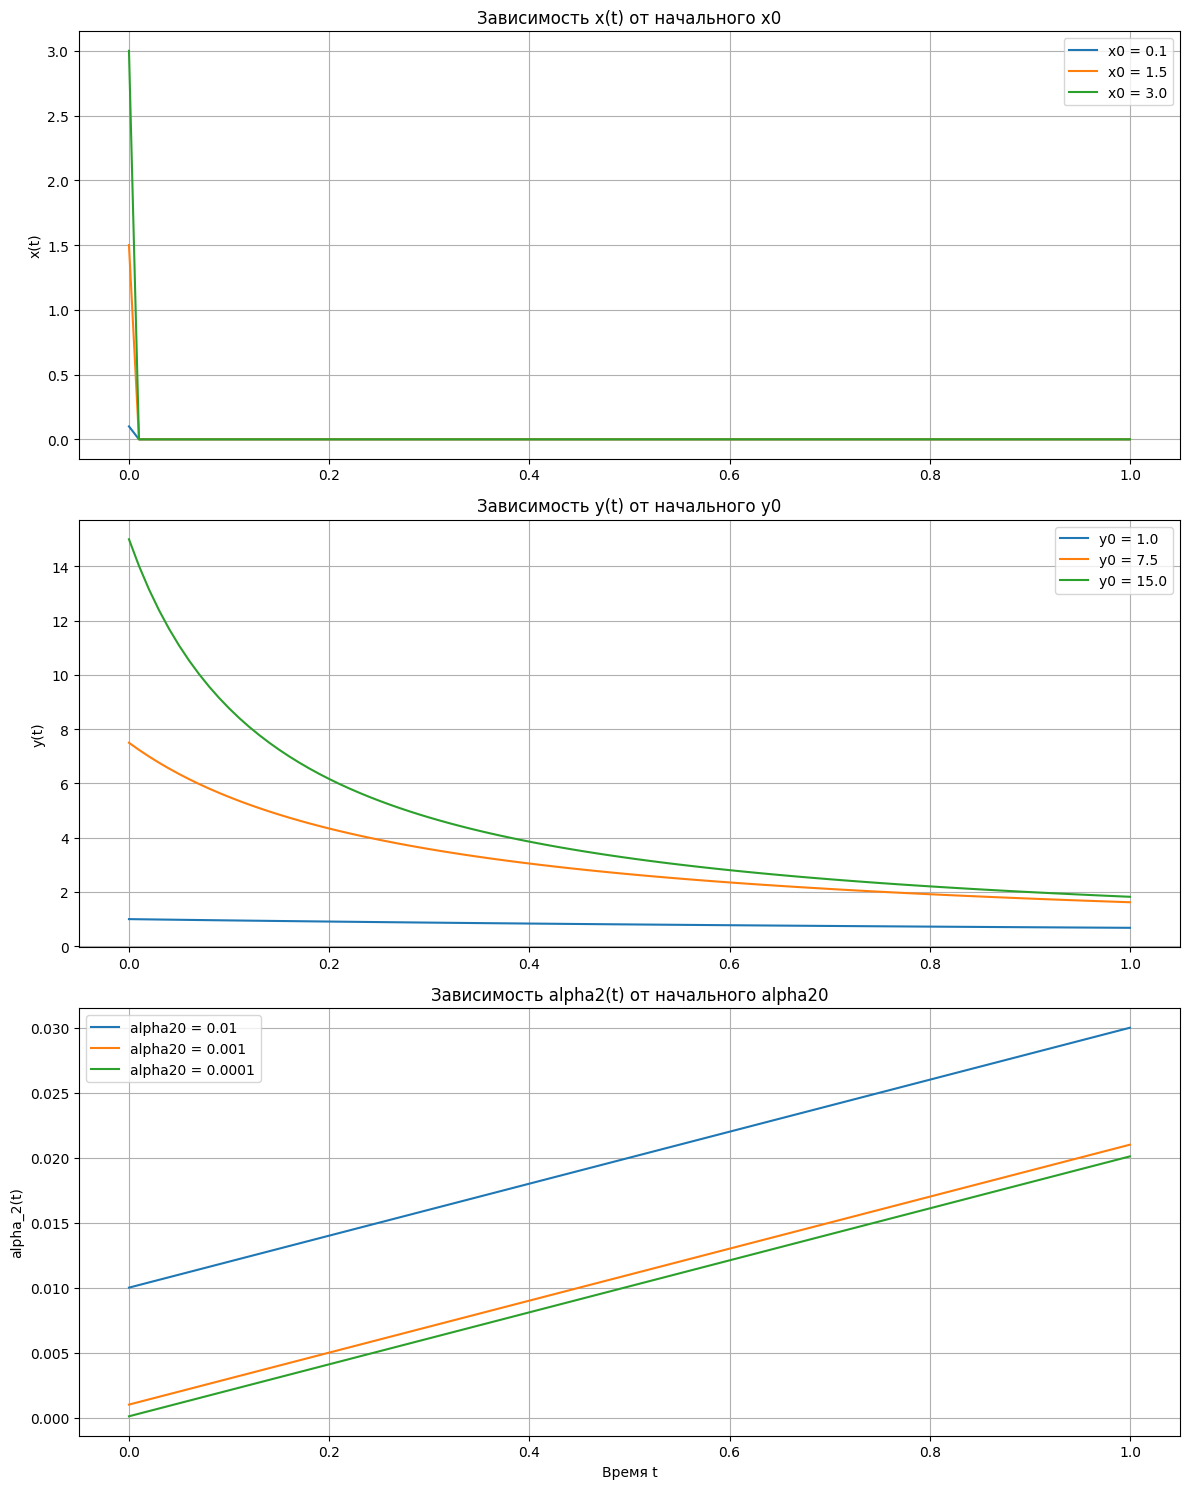

In [2]:
# --- ПУНКТ 3: ИССЛЕДОВАНИЕ ЗАВИСИМОСТИ ОТ НАЧАЛЬНЫХ УСЛОВИЙ ---

def investigate_initial_conditions():
    print("Запуск исследования начальных условий (Пункт 3)...")
    
    # Базовые параметры (фиксированные)
    epsilon = 0.01
    Tk = 1
    h = 0.01 # Шаг интегрирования для неявного метода можно брать крупным
    t_span = np.array([0.0, Tk], dtype=np.float64)
    
    # Наборы для тестирования
    x0_variants = [0.1, 1.5, 3.0]
    y0_variants = [1.0, 7.5, 15.0]
    alpha20_variants = [0.01, 0.001, 0.0001]
    
    fig, axes = plt.subplots(3, 1, figsize=(12, 15))
    
    # 1. Варьируем x0 (y0=7.5, a0=0.0001)
    for x0 in x0_variants:
        y0_arr = np.array([x0, 7.5, 0.0001], dtype=np.float64)
        t, y = implicit_euler_newton(y0_arr, t_span, h, epsilon)
        axes[0].plot(t, y[:, 0], label=f'x0 = {x0}')
    axes[0].set_title('Зависимость x(t) от начального x0')
    axes[0].set_ylabel('x(t)')
    axes[0].grid(True); axes[0].legend()
    
    # 2. Варьируем y0 (x0=1.5, a0=0.0001)
    for y0 in y0_variants:
        y0_arr = np.array([1.5, y0, 0.0001], dtype=np.float64)
        t, y = implicit_euler_newton(y0_arr, t_span, h, epsilon)
        axes[1].plot(t, y[:, 1], label=f'y0 = {y0}')
    axes[1].set_title('Зависимость y(t) от начального y0')
    axes[1].set_ylabel('y(t)')
    axes[1].grid(True); axes[1].legend()

    # 3. Варьируем alpha20 (x0=1.5, y0=7.5)
    for a0 in alpha20_variants:
        y0_arr = np.array([1.5, 7.5, a0], dtype=np.float64)
        t, y = implicit_euler_newton(y0_arr, t_span, h, epsilon)
        axes[2].plot(t, y[:, 2], label=f'alpha20 = {a0}')
    axes[2].set_title('Зависимость alpha2(t) от начального alpha20')
    axes[2].set_xlabel('Время t')
    axes[2].set_ylabel('alpha_2(t)')
    axes[2].grid(True); axes[2].legend()

    plt.tight_layout()
    plt.show()

# Запуск функции для пункта 3
investigate_initial_conditions()

Запуск исследования параметров (Пункт 4)...
Критическая ошибка: Якобиан содержит Inf/NaN на шаге 4
Критическая ошибка: Якобиан содержит Inf/NaN на шаге 4


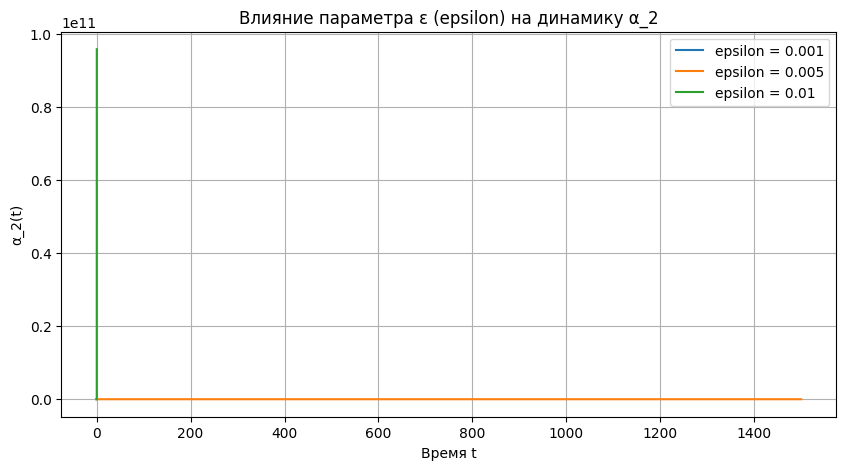

Критическая ошибка: Якобиан содержит Inf/NaN на шаге 4
Критическая ошибка: Якобиан содержит Inf/NaN на шаге 4
Критическая ошибка: Якобиан содержит Inf/NaN на шаге 4


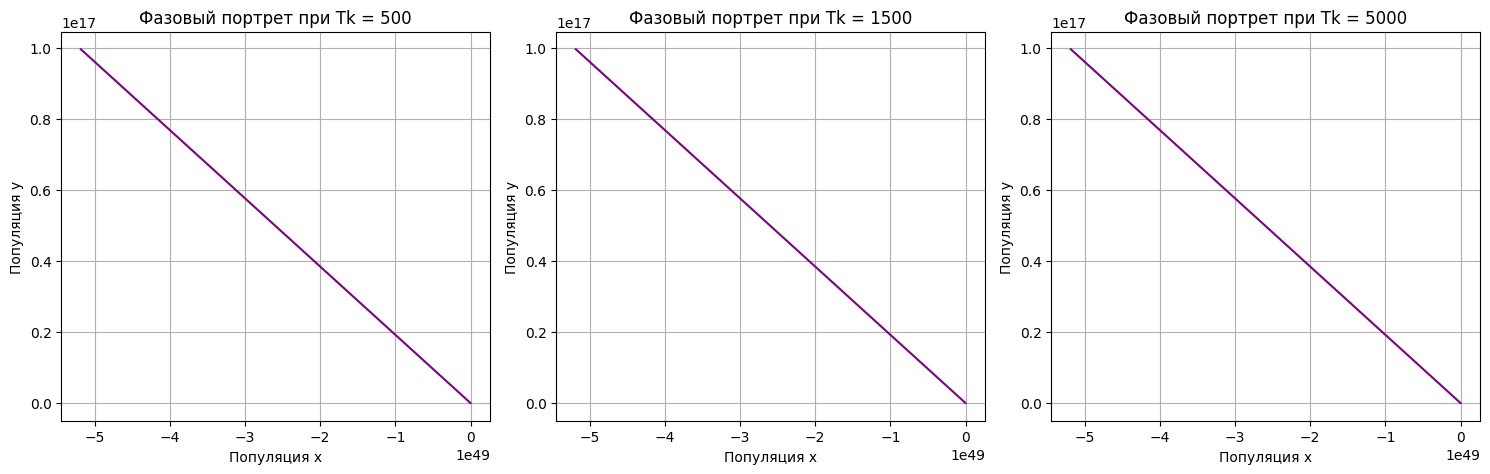

In [4]:
# --- ПУНКТ 4: ИССЛЕДОВАНИЕ ЗАВИСИМОСТИ ОТ ПАРАМЕТРОВ ---

def investigate_parameters():
    print("Запуск исследования параметров (Пункт 4)...")
    
    # Фиксируем начальные условия
    y0_base = np.array([1.5, 7.5, 0.0001], dtype=np.float64)
    h = 0.1
    
    # 1. Влияние параметра epsilon
    epsilon_variants = [0.001, 0.005, 0.01]
    Tk_fixed = 1500
    t_span_fixed = np.array([0.0, Tk_fixed], dtype=np.float64)
    
    fig1, ax1 = plt.subplots(figsize=(10, 5))
    for eps in epsilon_variants:
        t, y = implicit_euler_newton(y0_base, t_span_fixed, h, eps)
        # Смотрим, как epsilon влияет на динамику alpha_2
        ax1.plot(t, y[:, 2], label=f'epsilon = {eps}')
        
    ax1.set_title('Влияние параметра \u03B5 (epsilon) на динамику \u03B1_2')
    ax1.set_xlabel('Время t')
    ax1.set_ylabel('\u03B1_2(t)')
    ax1.grid(True)
    ax1.legend()
    plt.show()
    
    # 2. Влияние интервала интегрирования Tk (асимптотическое поведение)
    Tk_variants = [500, 1500, 5000]
    eps_fixed = 0.01
    
    fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))
    for i, Tk in enumerate(Tk_variants):
        t_span = np.array([0.0, Tk], dtype=np.float64)
        t, y = implicit_euler_newton(y0_base, t_span, h, eps_fixed)
        
        # Строим фазовый портрет (x от y), чтобы увидеть предельные циклы или аттракторы
        axes2[i].plot(y[:, 0], y[:, 1], color='purple')
        axes2[i].set_title(f'Фазовый портрет при Tk = {Tk}')
        axes2[i].set_xlabel('Популяция x')
        axes2[i].set_ylabel('Популяция y')
        axes2[i].grid(True)
        
    plt.tight_layout()
    plt.show()

# Запуск функции для пункта 4
investigate_parameters()

# Тесты


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit


@njit
def system_jacobian(state, epsilon):
    x, y, alpha2 = state
    if alpha2 < 1e-12: alpha2 = 1e-12
    
    J = np.zeros((3, 3))
    
    J[0, 0] = 1 - x - (2/7)*(alpha2**-2)*y
    J[0, 1] = -(2/7)*(alpha2**-2)*x
    J[0, 2] = (4/7)*(alpha2**-3)*x*y
    
    J[1, 0] = -3.5*(alpha2**2)*y
    J[1, 1] = 2*alpha2 - y - 3.5*(alpha2**2)*x
    J[1, 2] = 2*y - 7*alpha2*x*y
    
    J[2, 0] = -7*epsilon*alpha2
    J[2, 1] = 0.0
    J[2, 2] = -7*epsilon*x
    
    return J

# 3. ВАШ СОБСТВЕННЫЙ ЖЕСТКИЙ РЕШАТЕЛЬ (Неявный Эйлер)
@njit
def implicit_euler_newton(func,y0, t_span, h, epsilon, tol=1e-7, max_iter=20):
    n_steps = int((t_span[1] - t_span[0]) / h) + 1
    t = np.linspace(t_span[0], t_span[1], n_steps)
    y = np.zeros((n_steps, 3))
    y[0] = y0
    
    I = np.eye(3) # Единичная матрица
    
    for i in range(n_steps - 1):
        # Начальное приближение (Предиктор)
        y_guess = y[i] + h * func(t[i], y[i], epsilon)
        
        # Метод Ньютона (Корректор)
        for _ in range(max_iter):
            # Вектор невязки: F(y) = y_new - y_old - h * f(y_new)
            F = y_guess - y[i] - h * func(t[i+1], y_guess, epsilon)
            
            # Матрица системы: J_F = I - h * J_f
            J_f = system_jacobian(y_guess, epsilon)
            J_F = I - h * J_f
            if np.any(np.isnan(J_F)) or np.any(np.isinf(J_F)):
                print("Критическая ошибка: Якобиан содержит Inf/NaN на шаге", i)
                return t[:i], y[:i] # Вернуть то, что успели посчитать
            # Решение линейной системы J_F * dy = -F
            dy = np.linalg.solve(J_F, -F)
            y_guess = y_guess + dy
            
            # Условие выхода из итераций
            if np.linalg.norm(dy) < tol:
                break
                
        y[i+1] = y_guess
        
    return t, y

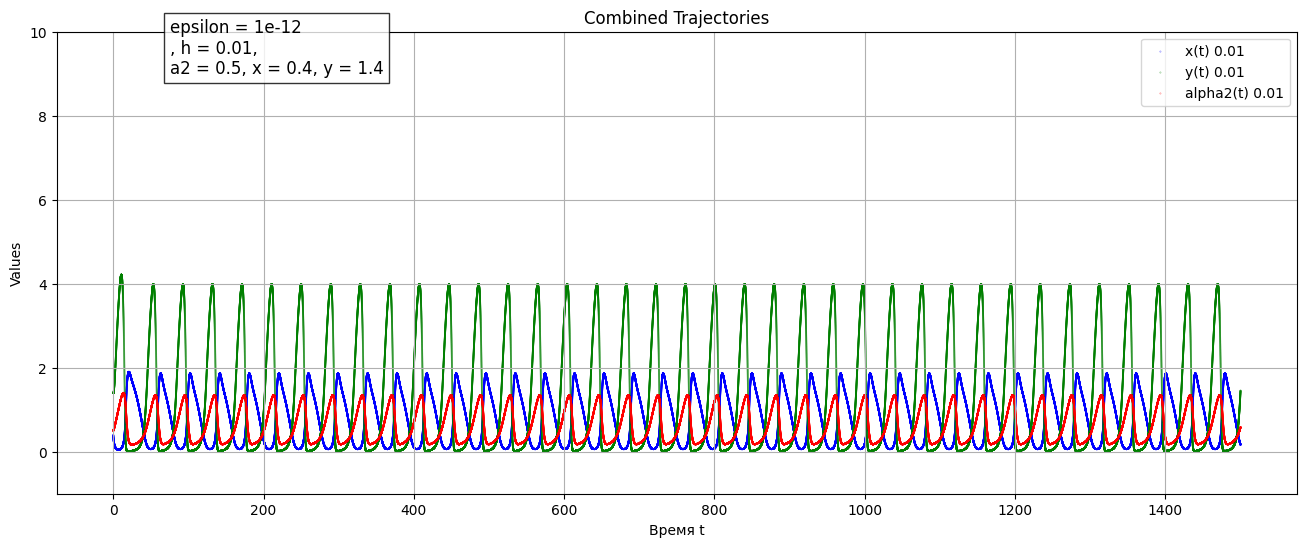

In [18]:
x0 = 0.4
y0 = 1.4
a0 = 0.5
eps = 0.05


y0_initial = np.array([x0, y0, a0], dtype=np.float64)
def draw_plots(y0_initial, t_max, h, method, **kwargs):
    plt.figure(figsize=(16, 6))
    t_range_plot = np.array([0, t_max], dtype=np.float64)
    t_plot, y_plot = method(system_func, y0_initial, t_range_plot, h=h)
    
    eps = 1e-12

    plt.scatter(t_plot, y_plot[:, 0], label=f'x(t) {h}', c=np.where(y_plot[:, 0] > eps, 'blue', 'black'),  **kwargs)
    plt.scatter(t_plot, y_plot[:, 1], label=f'y(t) {h}', c=np.where(y_plot[:, 1] > eps, 'green', 'black'), **kwargs)
    plt.scatter(t_plot, y_plot[:, 2], label=f'alpha2(t) {h}', c=np.where(y_plot[:, 2] > eps, 'red', 'black'), **kwargs)
    plt.xlabel('Время t')
    plt.ylabel('Values')
    plt.ylim(-1, 10)
    plt.text(0.05*t_max, 9, f'epsilon = {eps}\n, h = {h},\na2 = {y0_initial[2]}, x = {y0_initial[0]}, y = {y0_initial[1]}', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))
    plt.title('Combined Trajectories')
    plt.legend()
    plt.grid(True)

draw_plots(y0_initial, t_max=1500, h=0.01, method=lambda f, y0, t_span, h: implicit_euler_newton(f, y0, t_span, h, epsilon=eps), alpha=0.5, s=0.1)